In [5]:
!pip install pennylane optax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 870.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 61.9 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


#Train Classical, Deploy Quantum

1. Imports
2. Generators
3. Classical calculation of the expectation values
4. Exact simulation
5. Sampling from your circuit
6. Classical training
7. Bonus: PennyLane Labs
8. Resource estimation

In [6]:
# import your new favorite library (+ jax + jnp + optax)
import pennylane as qp
import jax
import jax.numpy as jnp
import optax

# create a jax PRNGKey
key = jax.random.PRNGKey(42)

#Generators

The generators define what kind of gates and observables will make up our circuit. We could use single-qubit gates, etc., up to the number of qubits. We can have a mix of these kinds of gates too!

In [7]:
# define your number of qubits
n_qubits = 4

# assemble gates and observables
gates = [
    [[0]],
    [[1]],
    [[2]],
    [[3]],
    [[0, 1]],
    [[0, 2]],
    [[0, 3]],
    [[1, 2]],
    [[1, 3]],
    [[2, 3]],
    [[0,1,2]],
    [[0,1,3]],
    [[0,2,3]],
    [[1,2,3]]]

#gates = [[[0]], [[0,1]], [[0,1,2]], [[1]]]

# generate pauli observables with n_qubits, orders=[2], bases=["Z"]
observables = jnp.array(
    [
        [3, 3, 0, 0],
        [3, 0, 3, 0],
        [3, 0, 0, 3],
        [0, 3, 3, 0],
        [0, 3, 0, 3],
        [0, 0, 3, 3]
    ]
)

# print the gates and observables
print("Gates:", gates)
print("Observables: ", observables)

Gates: [[[0]], [[1]], [[2]], [[3]], [[0, 1]], [[0, 2]], [[0, 3]], [[1, 2]], [[1, 3]], [[2, 3]], [[0, 1, 2]], [[0, 1, 3]], [[0, 2, 3]], [[1, 2, 3]]]
Observables:  [[3 3 0 0]
 [3 0 3 0]
 [3 0 0 3]
 [0 3 3 0]
 [0 3 0 3]
 [0 0 3 3]]


#Classical calculation of the expectation values

This calculates an unbiased estimate of the expectation values. Notice that there's no qnode and no device, this is purely classical.

In [8]:
# use jax.random.uniform to choose a random set of parameters for your gates
# use the key generated before and shape=(len(gates),)

params = jax.random.uniform(key, shape=(len(gates),))

# define the number of Monte Carlo samples for the estimation of the expectation value.
# let's use 4000 samples
n_samples = 5000

# calculate the expectation values (and standard errors for the estimates)
# use qp.qnn.iqp_expval(observables, params, gates, n_qubits, n_samples, key)

expvals, stderr = qp.qnn.iqp_expval(observables, params, gates, n_qubits, n_samples, key)

# print the expectation values
print(expvals)

[ 0.06853874  0.01032997  0.3866012   0.6371181  -0.01394103  0.10058302]


#Exact simulation

0.058959120918138944


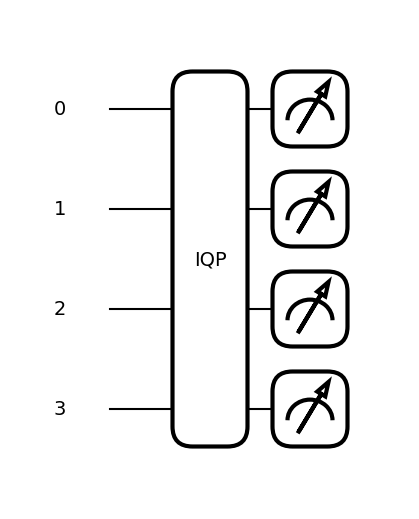

In [9]:
# create a "lightning.qubit" device
dev = qp.device("lightning.qubit", wires=n_qubits)
# create a qnode that takes the weights and pattern as arguments

@qp.qnode(dev)
def iqp_exact(weights, pattern):
  # use the IQP template
  # qp.IQP(weights=weights, num_wires=n_qubits, patter=pattern)
  qp.IQP(weights=weights, num_wires=n_qubits, pattern=pattern)

  # return the expectation value of ZZII
  return qp.expval(qp.Z(0) @ qp.Z(1) @ qp.I(2) @ qp.I(3))



# run your qnode with arguments: paras, list(gates.values())
expv = iqp_exact(params, gates)

# print the exact expectaiton value
print(expv)
# draw your qnode
qp.draw_mpl(iqp_exact)(params, gates);



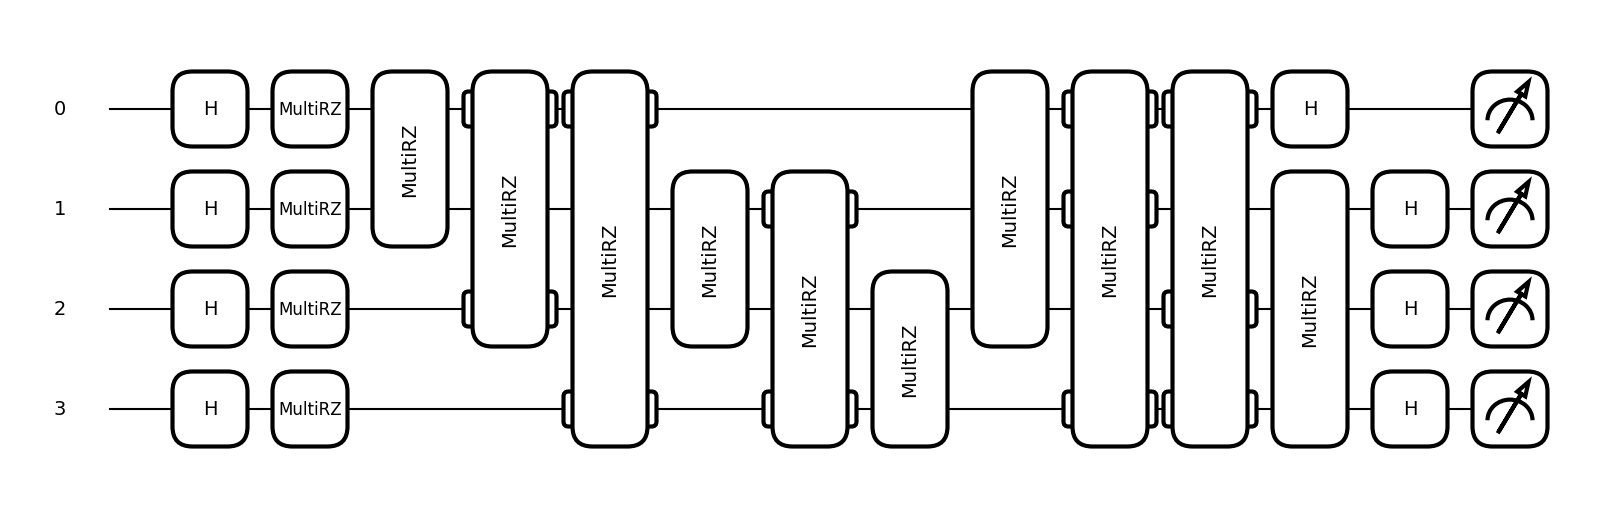

In [10]:
# decompose the circuit into gates
# choose gate_set=qp.gate_sets.ALL_QUBITS_OPS
iqp_decomp=qp.decompose(iqp_exact, gate_set=qp.gate_sets.ALL_QUBIT_OPS)

#draw your circuit

qp.draw_mpl(iqp_decomp)(params, gates);

[-1. -1.  1.  1.  1.  1. -1.  1. -1. -1.]


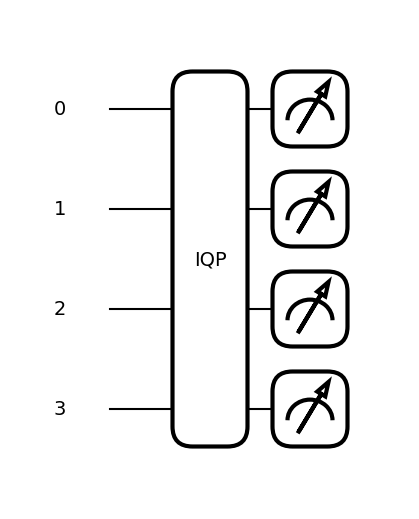

In [11]:
# sample from your circuit

# set the number of shots (10)
@qp.set_shots(10)
@qp.qnode(dev)
def iqp_sample(weights, pattern):
  # use the IQP template
  # qp.IQP(weights=weights, num_wires=n_qubits, patter=pattern)
  qp.IQP(weights=weights, num_wires=n_qubits, pattern=pattern)

  # return the expectation value of ZZII
  return qp.sample(qp.Z(0) @ qp.Z(1) @ qp.I(2) @ qp.I(3))

# copy the same qnode as before but instead of returning expval return sample




# run your qnode
samples = iqp_sample(params, gates)

# print the exact expectaiton value
print(samples)
# draw your qnode
qp.draw_mpl(iqp_exact)(params, gates);


#Classical training

So far we used random paramters for the gates, but we can train them clasically to minimize a loss function of our choice.

In [21]:
# choice a random set of parameters for your gates
params = jax.random.uniform(key, shape=(len(gates),))

def expval_fn(params):
  expvals, stderr = qp.qnn.iqp_expval(observables, params, gates, n_qubits, n_samples, key)
  return expvals, stderr


#executes the expectation value computaiton (and standard errors for the estimates)
expvals, std_errs = expval_fn(params)
print("Expectation values:", expvals)

Expectation values: [ 0.06853874  0.01032997  0.3866012   0.6371181  -0.01394103  0.10058302]


In [23]:
# define a loss function
def loss_fn(current_params):
  expvals, _ = expval_fn(current_params)

  # loss value
  loss_val = jnp.sum(expvals)

  return loss_val

# train

# define the optimizer we want to work with
opt = optax.adam(learning_rate=0.3)

# define the update step
@jax.jit
def update_step_jit(i, args):
  params, opt_state = args

  #find the new parameters based on the previous loss and gradients
  loss_val, grads = jax.value_and_grad(loss_fn)(params)
  updates, opt_state = opt.update(grads, opt_state)
  params = optax.apply_updates(params, updates)


  # print the loss every 5 steps
  def print_fn():
    jax.debug.print("Step: {i}  Loss: {loss_val}", i=i, loss_val=loss_val)

  jax.lax.cond((jnp.mod(i, 5) == 0), print_fn, lambda: None)

  return (params, opt_state)


# define your higher-level optimization loop
@jax.jit
def optimization_jit(params):

  opt_state = opt.init(params)
  args = (params, opt_state)
  (params, opt_state) = jax.lax.fori_loop(0, 100, update_step_jit, args)

  return params

# run the optimizer!
final_params = optimization_jit(params)

print("----------------")
print("Optimized parameters:", final_params)
print("----------------")

# calculate the expectation values with the optimized parameters
expvals, std_errs = expval_fn(final_params)
print("Expectation values:", expvals)

Step: 0  Loss: 1.1892300844192505
Step: 5  Loss: -1.2066324949264526
Step: 10  Loss: -1.3087023496627808
Step: 15  Loss: -1.5754462480545044
Step: 20  Loss: -1.7869749069213867
Step: 25  Loss: -1.8643954992294312
Step: 30  Loss: -1.9526817798614502
Step: 35  Loss: -1.971117377281189
Step: 40  Loss: -1.9730463027954102
Step: 45  Loss: -1.985571265220642
Step: 50  Loss: -1.994189977645874
Step: 55  Loss: -1.9984384775161743
Step: 60  Loss: -1.9997541904449463
Step: 65  Loss: -2.0001487731933594
Step: 70  Loss: -2.0003950595855713
Step: 75  Loss: -2.0006628036499023
Step: 80  Loss: -2.0008630752563477
Step: 85  Loss: -2.0010149478912354
Step: 90  Loss: -2.001110553741455
Step: 95  Loss: -2.001178741455078
----------------
Optimized parameters: [ 1.1275989e-04  1.5703076e+00 -3.9332514e-03  5.9753162e-04
  2.6014045e-02 -1.1359889e-01 -9.3545491e-01 -8.7969553e-01
  1.6814440e+00  1.5981435e+00  2.2384122e-03  1.5719570e+00
  1.5741216e+00  1.5696744e+00]
----------------
Expectation value

#Bonus: A peak into [PennyLane Labs](https://pennylane.ai/)
This is where you can get access to the latest code features and implementation, while the research is happening.

In [24]:
import pennylane.labs.phox as tcdq

#Resource Estimation

In [25]:
# import pennylane.estimator as qre
# iqp = qre.IQP(num_wires=4, pattern=[[[0]], [[1]], [[2]], [[3]]])
# print(qre.estimate(iqp))import pennylane.estimator as qre
import pennylane.estimator as qre
iqp = qre.IQP(num_wires=4, pattern=[[[0]], [[1]], [[2]], [[3]]])
print(qre.estimate(iqp))

--- Resources: ---
 Total wires: 4
   algorithmic wires: 4
   allocated wires: 0
     zero state: 0
     any state: 0
 Total gates : 184
   'T': 176,
   'CNOT': 0,
   'Hadamard': 8
